# Content policy enforcement with Claude

Content moderation is the process of checking content against a written policy before it
goes out, then deciding what happens to it: publish, reject, or send to a human
reviewer. The content can come from anywhere: user comments, seller listings, ad
creatives, marketing campaigns that legal must clear. The policy is written in plain
English by a policy, legal, or brand team, and content arrives faster than any review
team can read. Every owner of this loop lives with the same tension: **policy is written
by people, in prose, but enforcement needs to be consistent, cheap, and auditable.**

In this guide, you'll build a content moderation pipeline where Claude compiles that
written policy into deterministic, auditable rules. You'll compile a realistic
ad-clearance policy, extract typed fields from content (including creative images), and
produce verdicts from a rule engine that never calls a model, then run the same pipeline
over three domains and measure it against labeled samples.

> **All data in this notebook is synthetic.** The companies, brands, policies, and
> creative images are made up for this guide. The rules shown illustrate the pattern and
> do not represent real advertising or moderation requirements, so don't use them as
> compliance guidance.

## What you'll learn

- Designing an extraction schema whose descriptions double as extraction instructions
- A small JSON rule language with **scopes** and three-valued logic
- Compiling policy prose with a **validator-driven repair loop**
- **LLM assertions**: rules like "no one who looks under 25" as model-judged fields
- Extraction with structured outputs, including from images
- Adding a rule from one plain-English sentence
- Evaluating against labeled samples across three domains

## Prerequisites

- Python 3.10+ and an Anthropic API key (`ANTHROPIC_API_KEY` in your environment or a
  `.env` file; the setup cell loads it).
- Data ships alongside the notebook (`data/<domain>/`): schemas, policy documents,
  labeled samples, and synthetic creative images (all brands fictional, generated with
  Pillow, so ground-truth labels are correct by construction).

The engine and the two Claude stages live in `engine.py` and `pipeline.py` next to this
notebook. The guide imports them and shows the parts worth reading. If you're reading
this on the cookbook site, the full files are on GitHub:
[engine.py](https://github.com/anthropics/claude-cookbooks/blob/main/capabilities/content_moderation/engine.py) and [pipeline.py](https://github.com/anthropics/claude-cookbooks/blob/main/capabilities/content_moderation/pipeline.py).

**Cost and runtime.** The notebook makes real API calls: roughly 10 to 15 minutes and
about a dollar with defaults; `RUN_FULL_EVAL=1` (Step 10) doubles that. The committed
outputs are from a full run, so you can also just read along.


## The approach

The obvious LLM build is to paste the policy into a prompt and ask for a verdict. It
works in a demo and causes problems at production volume:

| Prompt-based verdicts | What production needs |
|---|---|
| The same content can get different verdicts on different runs | Identical inputs, identical decisions |
| Rejections explained by whatever prose the model generated | An evidence trail: rule, assertion, expected vs. actual |
| A policy change is an unreviewable prompt edit | Versioned, diffable rule artifacts you can replay |

This cookbook restructures the problem so Claude runs in exactly two places, and
**never decides the verdict**:


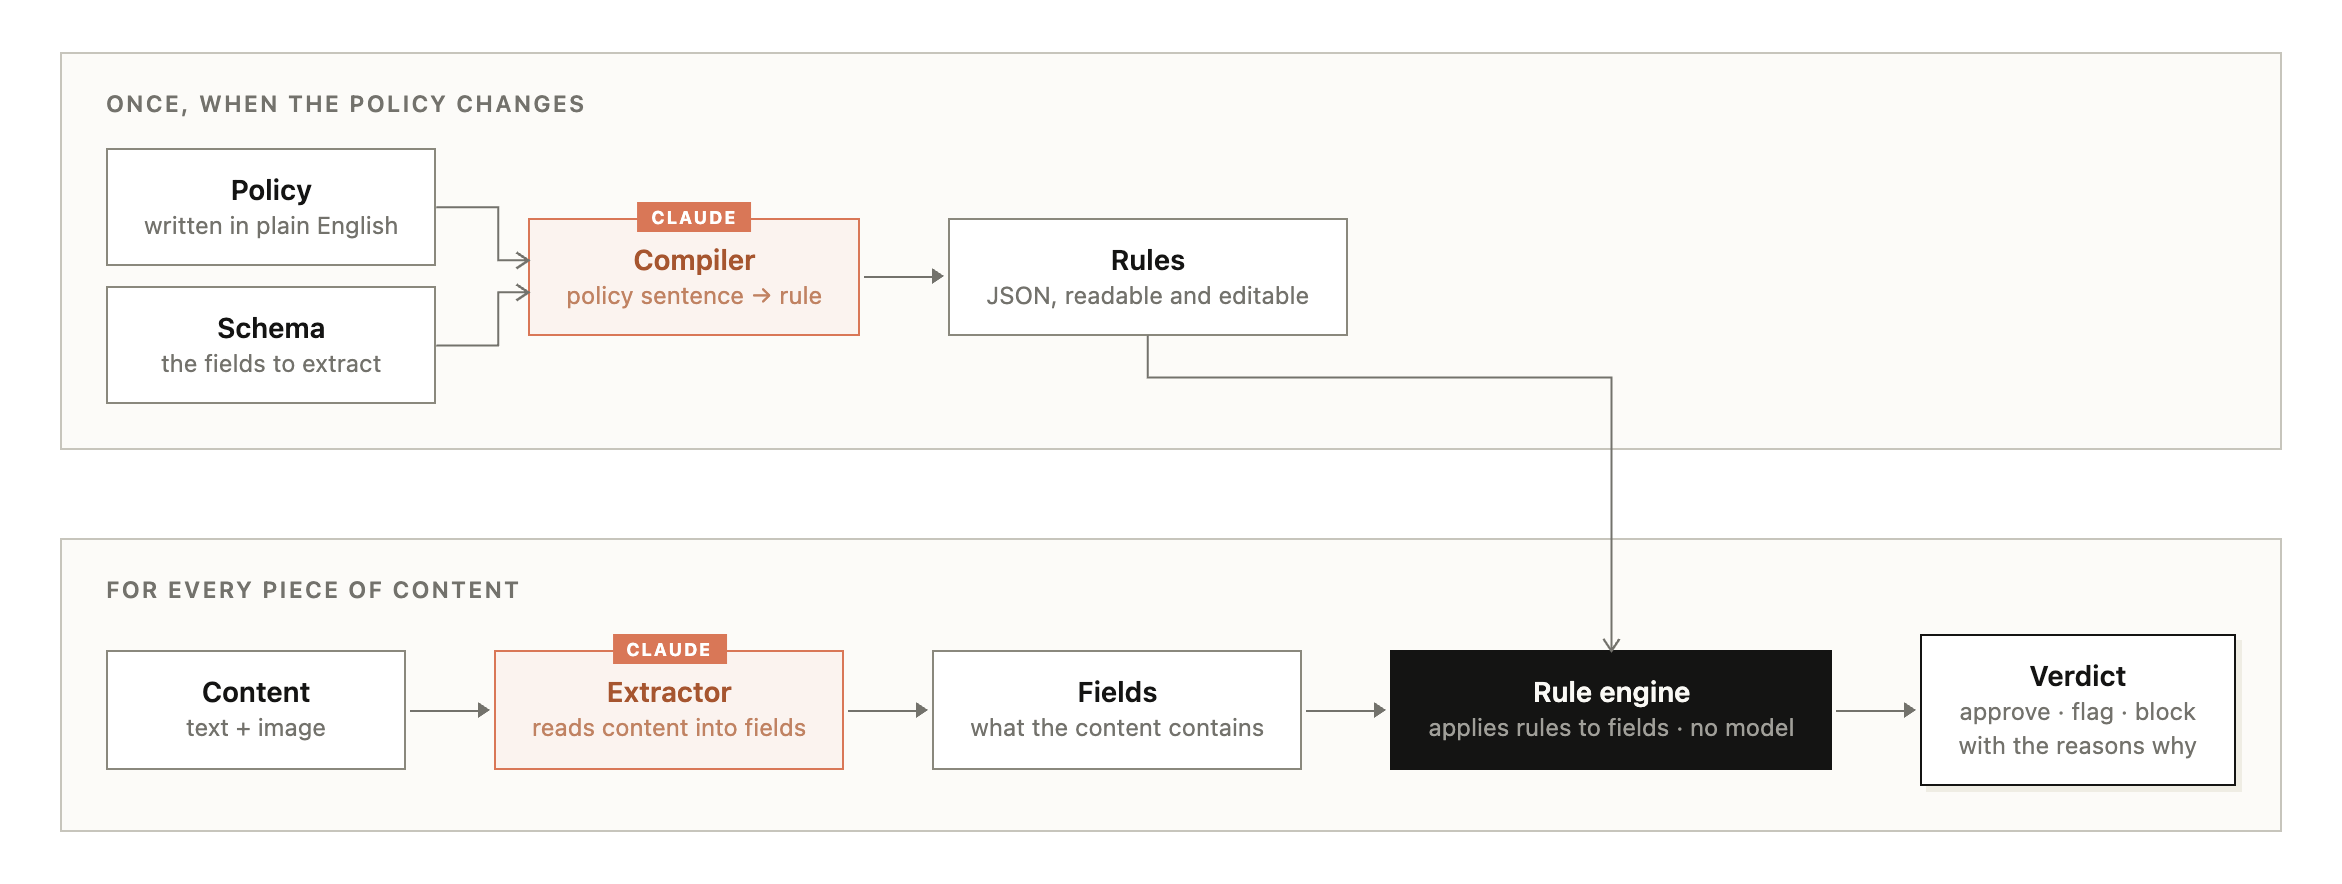

In [ ]:
from IPython.display import Image

Image("images/architecture.png")

1. **Schema** (you write it): the typed fields that can be known about a piece of content.
2. **Compiler** (Claude, once per policy change): turns each policy clause into rules
   over those fields, checked by a static validator.
3. **Extractor** (Claude, once per piece of content): one call reads text and image into
   typed fields.
4. **Engine** (no model): applies rules to fields. Same inputs, same verdict, with a
   per-assertion audit trail.

Rules engines were always trustworthy; what they never had was a way to read policy like
a policy person and content like a reviewer. That's the part Claude supplies.

The worked example is ad-creative clearance for **Northwind**, a fictional media
network. Two more domains, marketplace listings and community content, reuse every line
of code.


In [1]:
%%capture
%pip install -U "anthropic>=0.109.0" python-dotenv

import json
import pathlib

from dotenv import load_dotenv

load_dotenv()

from engine import evaluate, validate_document
from pipeline import compile_policies, compile_single_rule, extract_fields

DATA = pathlib.Path("data")


def show(obj, limit=2000):
    s = json.dumps(obj, indent=2)
    print(s[:limit] + ("\n… (truncated)" if len(s) > limit else ""))

## Step 1: Define the extraction schema

Everything in this pipeline builds on the schema, so we start there. The schema is the
contract between the model and the rule engine: the complete set of facts that can be
known about a piece of content. Two design points matter more than anything else:

- **The field descriptions do double duty.** They are the extraction instructions Claude
  follows at runtime, and they are what the compiler reads to decide which field a policy
  clause maps to. Write them like you're briefing a careful reviewer.
- **Fields can be null on purpose.** A field like `apr_disclosed` is `boolean | null`
  because "couldn't tell" is a legitimate answer, and the engine treats it differently
  from `false` (more on three-valued logic below).

Fields mix objective facts (`price_or_rate_shown`) with bounded judgments
(`text_coverage`). The schema is where you decide how much judgment to allow.


In [2]:
schema = json.loads((DATA / "ad_creatives" / "schema.json").read_text())

for name, spec in schema["properties"].items():
    t = " | ".join(spec["type"]) if isinstance(spec["type"], list) else spec["type"]
    t = f"enum[{', '.join(spec['enum'])}]" if "enum" in spec else t
    print(f"{name:<36} {t}")
print(f"\n{len(schema['properties'])} fields")

ad_category                          enum[alcohol, gambling, financial_services, pharma_supplements, weight_loss, cosmetics_skincare, apparel_footwear, electronics, food_beverage, other]
brand_name                           string | null
headline_text                        string
disclaimer_present                   boolean
disclaimer_text                      string | null
age_gate_shown                       integer | null
text_coverage                        enum[low, medium, high]
before_after_imagery                 boolean
superlative_claims                   array
health_claim_present                 boolean
price_or_rate_shown                  boolean
apr_disclosed                        boolean | null
people_depicted                      boolean
depicted_person_apparent_minor       boolean | null
competitor_reference                 boolean
landing_url_domain                   string | null
target_min_age                       integer | null

17 fields


### The context schema

Not everything a rule needs can be read out of the content itself. Where the ad will
run, which channel it runs on, whether the advertiser is managed or self-serve: your
platform already knows these things before any review starts. They are facts about the
placement, not the content.

These go in a second, smaller schema called the **context schema**. Your code passes
them in when it asks for a verdict, and nothing is ever extracted for them. In Step 2
you'll see how a rule can be limited to a particular context, like "only in New Jersey".


In [3]:
context_schema = json.loads((DATA / "ad_creatives" / "context.json").read_text())
show({k: v.get("enum", v["type"]) for k, v in context_schema["properties"].items()})

{
  "country": "string",
  "state": [
    "string",
    "null"
  ],
  "channel": [
    "display",
    "social",
    "video",
    "email"
  ],
  "advertiser_tier": [
    "managed",
    "self_serve"
  ]
}


## Step 2: The rule language

Before asking Claude to compile anything, let's look at what it needs to produce.
A compiled ruleset is one JSON document:

```json
{
  "derived_fields": { /* LLM-judged booleans the compiler needed, see Step 4 */ },
  "rules": [
    {
      "id": "5.1_nj_gambling_helpline",
      "policy_ref": "5.1",
      "policy_text": "Gambling creatives running in New Jersey must display the 1-800-GAMBLER helpline.",
      "action": "block",                       // block = reject; flag = human review
      "scope": {                               // WHERE the rule applies (context ∪ fields)
        "all": [
          {"field": "state", "op": "eq", "value": "NJ"},
          {"field": "ad_category", "op": "eq", "value": "gambling"}
        ]
      },
      "when": {                                // the VIOLATION (fields only)
        "not": {"field": "disclaimer_text", "op": "regex", "value": "1-800-GAMBLER"}
      }
    }
  ],
  "uncompilable": [ /* clauses that map to no field and no judgment; surfaced, not dropped */ ]
}
```

Conditions compose with `all` / `any` / `not` over leaf assertions
(`eq, neq, gt, gte, lt, lte, in, not_in, contains, not_contains, regex, exists`).
Three design choices matter:

- **`when` is the violation** (rule fires means policy breached), the same convention
  as linters and firewall rules. Traces read "fired because X".
- **Scope is split from violation.** "Alcohol ads must have a disclaimer" is two
  statements: *for whom*, and *what's wrong*. Scope can also read placement context
  that extraction can never know.
- **Three-valued logic.** Missing values evaluate to *unknown*, and a rule that would
  fire but can't be confirmed yields `needs_review` instead of a confident verdict.


## Step 3: The rule engine

Now the part that decides. The engine (`engine.py`, about 200 lines) is a pure function
of `(rules, fields, context)`, with no model and no I/O. This is the part your
compliance team gets to unit-test, and the reason two identical pieces of content can
never get different verdicts. Its heart:

```python
def evaluate_rule(rule, fields, context=None):
    rr = RuleResult(rule["id"], rule.get("action", "flag"), "clear")
    if "scope" in rule:
        rr.scope_result = _eval(rule["scope"], {**fields, **(context or {})}, rr.scope_trace)
        if rr.scope_result is False:
            rr.outcome = "out_of_scope"
            return rr
    w = _eval(rule["when"], fields, rr.trace)
    if rr.scope_result is None:  # can't confirm applicability: only a definite pass is safe
        rr.outcome = "clear" if w is False else "unknown"
    else:
        rr.outcome = "fired" if w is True else "clear" if w is False else "unknown"
    return rr

def evaluate(rules, fields, context=None):
    results = [evaluate_rule(r, fields, context) for r in rules]
    fired   = [r for r in results if r.outcome == "fired"]
    unknown = [r for r in results if r.outcome == "unknown"]
    if any(r.action == "block" for r in fired): decision = "block"
    elif fired:                                 decision = "flag"
    elif unknown:                               decision = "needs_review"
    else:                                       decision = "approve"
    ...
```

`_eval` walks the condition tree, appends every assertion to the trace (with its
`all`/`any`/`not` structure), and propagates unknowns the way SQL propagates nulls.
[engine.py](https://github.com/anthropics/claude-cookbooks/blob/main/capabilities/content_moderation/engine.py) also holds `validate_document`, the static checker the
compiler's repair loop uses in Step 5.


### Trying it out

No model is involved yet, so we can play with the engine directly. Hand-write one rule
and one fields dict, and watch the trace, including what happens when a value is `null`
and when context changes the scope.


In [4]:
demo_rules = [
    {
        "id": "bonus_cap_flag",
        "policy_text": "Sign-up bonuses over $1000 are flagged for review.",
        "action": "flag",
        "when": {"field": "bonus_amount_usd", "op": "gt", "value": 1000},
    },
    {
        "id": "nj_bonus_cap_block",
        "policy_text": "In New Jersey, sign-up bonuses over $1000 are blocked.",
        "action": "block",
        "scope": {"field": "state", "op": "eq", "value": "NJ"},
        "when": {"field": "bonus_amount_usd", "op": "gt", "value": 1000},
    },
]

fields = {"bonus_amount_usd": 1500}

print("── California:")
print(evaluate(demo_rules, fields, {"state": "CA"}).explain())
print("\n── New Jersey — same fields, different scope:")
print(evaluate(demo_rules, fields, {"state": "NJ"}).explain())
print("\n── Bonus amount unreadable (null) — three-valued logic routes to review:")
print(evaluate(demo_rules, {"bonus_amount_usd": None}, {"state": "NJ"}).explain())

── California:
DECISION: FLAG
  ✗ [flag] bonus_cap_flag
      T  bonus_amount_usd gt 1000  (actual: 1500)
  – out of scope: nj_bonus_cap_block

── New Jersey — same fields, different scope:
DECISION: BLOCK
  ✗ [flag] bonus_cap_flag
      T  bonus_amount_usd gt 1000  (actual: 1500)
  ✗ [block] nj_bonus_cap_block
      scope:
        T  state eq 'NJ'  (actual: 'NJ')
      T  bonus_amount_usd gt 1000  (actual: 1500)

── Bonus amount unreadable (null) — three-valued logic routes to review:
DECISION: NEEDS_REVIEW
  ? [flag] bonus_cap_flag  — could not determine: bonus_amount_usd
  ? [block] nj_bonus_cap_block  — could not determine: bonus_amount_usd


## Step 4: LLM assertions

The engine so far only compares values. But some policy clauses can't reduce to
comparisons over extractable facts: *"Alcohol creatives must not depict anyone who
appears to be under 25."* No field says that. Calling a model from inside the engine
would break everything we just built, so instead the compiler **manufactures a field**:
a `derived_fields` entry whose `judge` instruction is a precise yes/no question,
referenced like any other field:

```json
"derived_fields": {
  "depicted_person_apparent_under_25": {
    "type": ["boolean", "null"],
    "judge": "True if any person depicted appears to be under 25. Null if no people or indeterminate.",
    "source_policy": "1.1"
  }
},
// rule: {"all": [{"field": "people_depicted", "op": "eq", "value": true},
//                {"field": "depicted_person_apparent_under_25", "op": "eq", "value": true}]}
```

The judgment is answered during the same single extraction call as every other field,
so the engine stays pure and `null` still routes to review. Note the `people_depicted`
gate above: judgment rules gate on their precondition, so "no people in the creative"
evaluates the rule *clear* instead of sending every landscape shot to review.

The compiler tries these in order: an operator on an existing field, then a derived
judged field, then `uncompilable` (for clauses that need external data, like a
gaming-license registry lookup).


## Step 5: Compile the policy document

With the schema, the rule language, and the engine in place, we can compile the real
policy. It is written the way policy teams actually write: prose clauses, for humans.
Read it before compiling; note clause 1.1's under-25 line (needs a judgment), clause
1.2's licensing line (uncompilable), and section 5's regional rules (scopes).


In [5]:
policies = (DATA / "ad_creatives" / "policies.md").read_text()
print(policies)

# Ad Creative Acceptance Policy — Northwind Media Network

*Written the way a policy team actually writes: prose, for humans. The compiler's job is to turn each numbered clause into one or more machine-checkable rules over the extraction schema — and to say so explicitly when a clause can't be reduced to the available fields.*

## 1. Restricted categories

1.1 **Alcohol.** Alcohol advertising is accepted only when audience targeting is set to 21+ and the creative carries a responsible-drinking message (e.g. "Drink Responsibly", "Enjoy Responsibly"). Alcohol creatives must not depict anyone who appears to be under 25.

1.2 **Gambling & betting.** Must target 18+ (21+ preferred), must display an age badge in the creative, and must include a problem-gambling helpline or "gamble responsibly" style message. Claims of guaranteed winnings or "risk-free" bets are prohibited outright. Gambling advertisers must hold a valid gaming license in every state the campaign targets.

1.3 **Financial ser

The compiler prompt carries the schema, the context schema, and the rule-format spec with
six compilation rules (split scope from violation; one clause listing several values
compiles to one `in` rule, not copies; several requirements become several rules; prefer
operators, then derived fields, then `uncompilable`; never invent fields).

The part that makes it production-shaped is the **repair loop** in
`pipeline.compile_policies`: `validate_document` runs statically on the output, and any
problems (an invented field, an enum value outside its set, a context key leaking into a
`when`) go back to Claude as a fix-only turn. Hallucinations don't survive contact with
the validator.

```python
for round_no in range(max_repair_rounds + 1):
    doc = _parse_json_reply(claude_reply(messages))
    problems = validate_document(doc, schema, context_schema)
    if not problems:
        return doc, attempts
    messages += [assistant(reply), user("Fix ONLY these problems: " + json.dumps(problems))]
```


In [6]:
compiled, attempts = compile_policies(policies, schema, context_schema)

for a in attempts:
    status = "clean" if not a["problems"] else json.dumps(a["problems"])
    print(f"round {a['round']}: {status}")
print(
    f"\n{len(compiled['rules'])} rules · {len(compiled.get('derived_fields', {}))} derived fields · "
    f"{len(compiled.get('uncompilable', []))} uncompilable"
)
print("\nrule ids:", ", ".join(r["id"] for r in compiled["rules"]))
print("\nderived fields:")
for name, spec in compiled.get("derived_fields", {}).items():
    print(f"  {name}: {spec['judge'][:110]}")
print("\nuncompilable:")
for u in compiled.get("uncompilable", []):
    print(f"  [{u['policy_ref']}] {u['policy_text'][:80]}… → {u['reason'][:100]}")

round 0: clean

22 rules · 7 derived fields · 1 uncompilable

rule ids: 1.1a_alcohol_targeting_21, 1.1b_alcohol_responsibility_message, 1.1c_alcohol_under_25_depiction, 1.2a_gambling_targeting_18, 1.2b_gambling_age_badge, 1.2c_gambling_responsibility_message, 1.2d_gambling_guaranteed_winnings, 1.3a_credit_offer_apr_required, 1.3b_guaranteed_approval, 1.4a_before_after_imagery, 1.4b_medical_claim, 1.4c_weight_loss_minor_targeting, 2.1_superlative_claims_review, 2.2_competitor_reference_legal_review, 3.1a_text_coverage_high, 3.1b_text_coverage_medium, 3.2_advertiser_identification, 4.1_restricted_category_no_min_age, 4.2_apparent_minor_restricted_categories, 5.1_nj_gambling_helpline, 5.2_email_alcohol_gambling_prohibited, 5.3_self_serve_financial_review

derived fields:
  responsible_drinking_message_present: Does the creative (image text, headline, or body copy) carry a responsible-drinking message such as 'Drink Res
  depicts_person_apparently_under_25: Looking at the people shown in t

### What the validator catches

To see what the repair loop is defending against, corrupt a rule three different ways
and validate. In a live compile these exact messages go back to Claude to fix.


In [7]:
broken = {
    "derived_fields": {},
    "rules": [
        {
            "id": "bad1",
            "action": "block",
            "when": {"field": "creative_has_disclamer", "op": "eq", "value": True},
        },  # invented field
        {
            "id": "bad2",
            "action": "block",
            "when": {"field": "ad_category", "op": "eq", "value": "liquor"},
        },  # not in the enum
        {
            "id": "bad3",
            "action": "block",
            "scope": {"field": "ad_category", "op": "eq", "value": "gambling"},
            "when": {"field": "state", "op": "eq", "value": "NJ"},
        },  # context key in `when`
    ],
}
show(validate_document(broken, schema, context_schema))

{
  "bad1": [
    "bad1.when: unknown field 'creative_has_disclamer' (available: ['ad_category', 'age_gate_shown', 'apr_disclosed', 'before_after_imagery', 'brand_name', 'competitor_reference', 'depicted_person_apparent_minor', 'disclaimer_present', 'disclaimer_text', 'headline_text', 'health_claim_present', 'landing_url_domain', 'people_depicted', 'price_or_rate_shown', 'superlative_claims', 'target_min_age', 'text_coverage'])"
  ],
  "bad2": [
    "bad2.when: 'liquor' not in enum for 'ad_category': ['alcohol', 'gambling', 'financial_services', 'pharma_supplements', 'weight_loss', 'cosmetics_skincare', 'apparel_footwear', 'electronics', 'food_beverage', 'other']"
  ],
  "bad3": [
    "bad3.when: unknown field 'state' (available: ['ad_category', 'age_gate_shown', 'apr_disclosed', 'before_after_imagery', 'brand_name', 'competitor_reference', 'depicted_person_apparent_minor', 'disclaimer_present', 'disclaimer_text', 'headline_text', 'health_claim_present', 'landing_url_domain', 'people_d

### Comparing against a hand-written ruleset

`rules.golden.json` is our hand-written compilation of the same policy. The compiled
version typically covers the same clauses but often leans more on derived fields
(judging "has a responsible-drinking message" semantically instead of a brittle
`regex`). Arguably better, but it moves more surface onto model judgment; that the
trade-off is yours to review is the point of rules being an artifact.

**For the rest of this notebook we use the golden ruleset**, so results are reproducible
run to run; swap in `compiled` to use yours.


In [8]:
golden = json.loads((DATA / "ad_creatives" / "rules.golden.json").read_text())
assert not validate_document(golden, schema, context_schema)

g_refs = {r["policy_ref"] for r in golden["rules"]}
c_refs = {r.get("policy_ref") for r in compiled["rules"]}
print("clause coverage — golden:", sorted(g_refs))
print(
    "missing vs golden:",
    sorted(g_refs - c_refs) or "none",
    "· extra:",
    sorted(c_refs - g_refs) or "none",
)

active = golden  # ← the ruleset used below

clause coverage — golden: ['1.1', '1.2', '1.3', '1.4', '2.1', '2.2', '3.1', '3.2', '4.1', '4.2', '5.1', '5.2', '5.3']
missing vs golden: none · extra: none


## Step 6: Extract fields from content

We have rules. Now we need fields to run them against, and that is extraction
(`pipeline.extract_fields`): one Claude call per piece of content. This is the call that
scales with volume, so it uses Sonnet, while compilation (once per policy change) uses
Opus. The output schema is the extraction schema plus the ruleset's judged fields,
enforced with **structured outputs**, so fields come back typed:

```python
response = _client().messages.create(
    model=EXTRACTOR_MODEL,
    system="You extract facts. You decide nothing about policy; report only what you observe.",
    messages=[{"role": "user", "content": [image_block, {"type": "text", "text": prompt}]}],
    output_config={"format": {"type": "json_schema",
                              "schema": build_extraction_schema(schema, derived_fields)}},
)
```

Derived judgments ride along as fields whose description starts with `JUDGMENT:`, and
`null` means "genuinely can't tell", never "didn't bother". Full source:
[pipeline.py](https://github.com/anthropics/claude-cookbooks/blob/main/capabilities/content_moderation/pipeline.py).


Run it on a synthetic sportsbook creative. Everything policy-relevant here was placed
deliberately when the image was composed: a **$1,500** bonus figure, a **21+** badge, and
a small-print strip that says *"Gamble Responsibly."* but **not** the 1-800-GAMBLER
helpline that New Jersey requires.


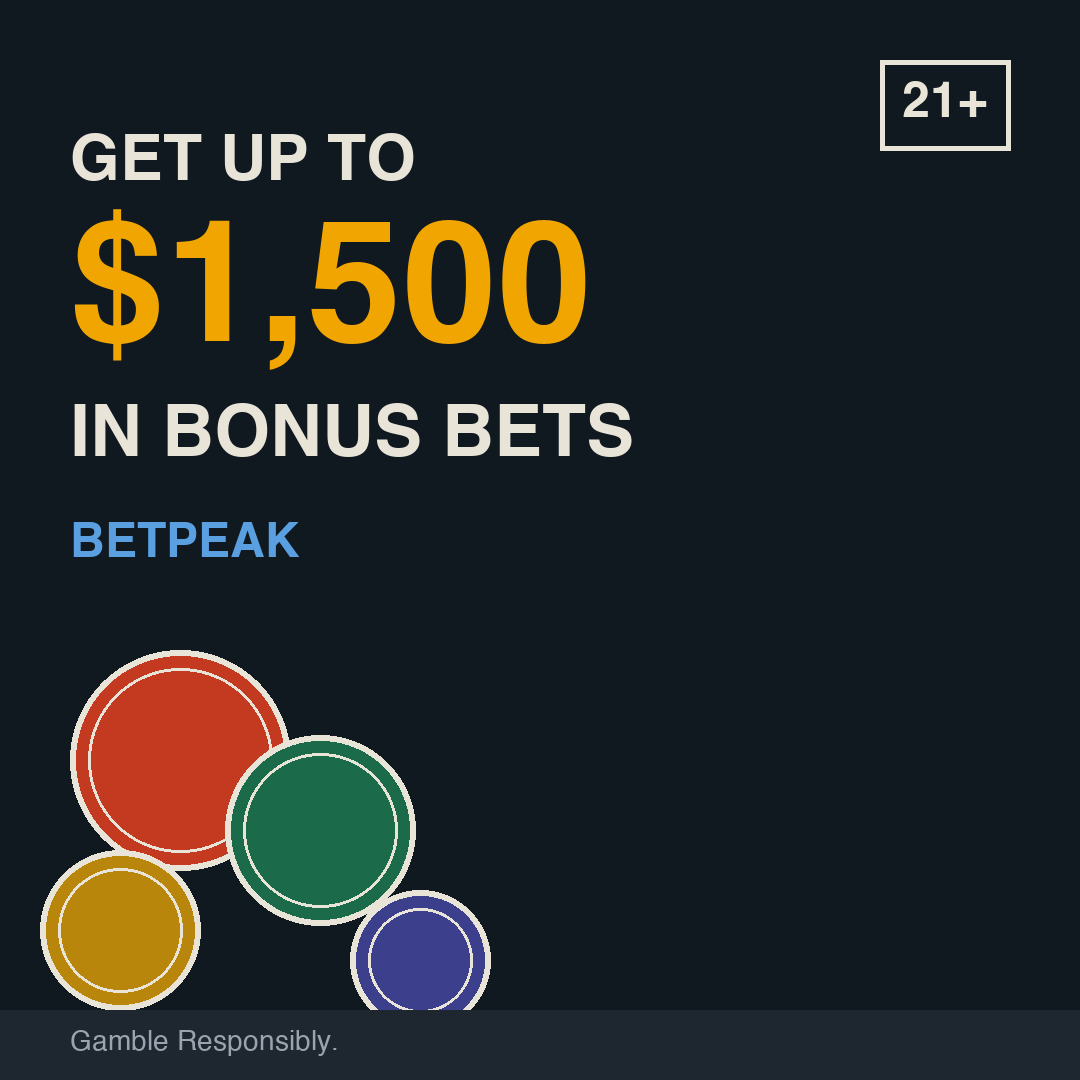

{
  "ad_category": "gambling",
  "brand_name": "BetPeak",
  "headline_text": "Get up to $1,500 in bonus bets",
  "disclaimer_present": true,
  "disclaimer_text": "Gamble Responsibly.",
  "age_gate_shown": 21,
  "text_coverage": "medium",
  "before_after_imagery": false,
  "superlative_claims": [],
  "health_claim_present": false,
  "price_or_rate_shown": true,
  "apr_disclosed": null,
  "people_depicted": false,
  "depicted_person_apparent_minor": null,
  "competitor_reference": false,
  "landing_url_domain": null,
  "target_min_age": 21,
  "depicted_person_apparent_under_25": null
}


In [9]:
from IPython.display import Image as IPImage
from IPython.display import display

img_path = DATA / "ad_creatives" / "images" / "betpeak_bonus.png"
display(IPImage(str(img_path), width=380))

submission = {
    "headline": "Get up to $1,500 in bonus bets",
    "body": "New BetPeak members get up to $1,500 in bonus bets on signup. 21+.",
    "brand": "BetPeak",
    "targeting": {"min_age": 21, "geo": "US-NJ"},
}
fields = extract_fields(submission, schema, active.get("derived_fields", {}), image_path=img_path)
show(fields)

## Step 7: Evaluate

Fields extracted, rules compiled: the verdict is now just a function call. Every fired
rule names its policy clause and every assertion shows expected vs. actual. And because
evaluation is free, **changing the placement context doesn't re-invoke the model**: the
same fields evaluated for New Jersey and for California give different verdicts, for
reasons you can point at.


In [10]:
print("── New Jersey placement:")
print(
    evaluate(
        active["rules"],
        fields,
        {"country": "US", "state": "NJ", "channel": "display", "advertiser_tier": "managed"},
    ).explain()
)

print("\n── Same fields, California placement — zero model calls:")
print(
    evaluate(
        active["rules"],
        fields,
        {"country": "US", "state": "CA", "channel": "display", "advertiser_tier": "managed"},
    ).explain()
)

── New Jersey placement:
DECISION: BLOCK
  ✗ [flag] 3.1b_text_coverage_medium
      T  text_coverage eq 'medium'  (actual: 'medium')
  ✗ [block] 5.1_nj_gambling_helpline
      scope:
        T  all:
          T  state eq 'NJ'  (actual: 'NJ')
          T  ad_category eq 'gambling'  (actual: 'gambling')
      T  any:
        F  disclaimer_present eq False  (actual: True)
        T  not:
          F  disclaimer_text regex '1-800-GAMBLER'  (actual: 'Gamble Responsibly.')
  – out of scope: 1.1a_alcohol_targeting_21, 1.1b_alcohol_responsible_message, 1.1c_alcohol_no_under_25, 1.3a_finance_apr_required, 1.3b_finance_no_guaranteed_approval, 1.4c_weight_loss_targeting_18, 5.2_no_alcohol_gambling_email, 5.3_self_serve_finance_review

── Same fields, California placement — zero model calls:
DECISION: FLAG
  ✗ [flag] 3.1b_text_coverage_medium
      T  text_coverage eq 'medium'  (actual: 'medium')
  – out of scope: 1.1a_alcohol_targeting_21, 1.1b_alcohol_responsible_message, 1.1c_alcohol_no_under_2

## Step 8: Add a rule in plain English

Policy changes rarely arrive as a rewritten document. They arrive as a sentence from the
policy team. `pipeline.compile_single_rule` runs the same compiler pattern one clause at a time:
compile the sentence against the schema (reusing existing derived fields where they
fit), validate with the same repair loop, and append the additions as a **new version**
of the ruleset. Note that one sentence can legitimately compile to
*several* rules (flag generally, but block in one state), and the compiler is told not to
collapse or drop any part.


In [11]:
addition = compile_single_rule(
    "Sign-up bonus offers greater than $1000 must be flagged for review, "
    "and in New Jersey they are blocked outright.",
    active,
    schema,
    context_schema,
)
show(addition)

# Append as a new ruleset version (never edit in place; rulesets are versioned artifacts)
active_v2 = {
    "derived_fields": {**active["derived_fields"], **addition["derived_fields"]},
    "rules": active["rules"] + addition["rules"],
    "uncompilable": active.get("uncompilable", []),
}
assert not validate_document(active_v2, schema, context_schema)
print(f"\nruleset v2: {len(active_v2['rules'])} rules")

{
  "derived_fields": {
    "signup_bonus_over_1000": {
      "type": [
        "boolean",
        "null"
      ],
      "judge": "Look at the headline, body copy, and any text in the creative image. Answer true if the ad promotes a sign-up / welcome / new-customer / registration bonus (cash, credit, bonus funds, free bets, match bonus, or equivalent) whose stated maximum value is greater than $1000 (e.g. 'Get up to $1,500 in bonus bets when you sign up'). Answer false if a sign-up bonus is offered but its stated value is $1000 or less, or if the ad promotes no sign-up bonus at all. Answer null if a sign-up bonus is clearly offered but its monetary value cannot be determined from the content (e.g. 'huge welcome bonus' with no amount, or amount given only in a non-monetary unit you cannot convert).",
      "source_policy": "custom"
    }
  },
  "rules": [
    {
      "id": "custom_signup_bonus_over_1000_flag",
      "policy_ref": "custom",
      "policy_text": "Sign-up bonus offers grea

The BetPeak creative advertises a $1,500 bonus, so the new rule should catch it. The
derived judgment wasn't in the extraction we ran earlier, so re-extract against v2's
derived fields, then evaluate. Note the flag in California vs. the block in New Jersey.


In [12]:
fields_v2 = extract_fields(submission, schema, active_v2["derived_fields"], image_path=img_path)
print("── New Jersey, ruleset v2:")
print(
    evaluate(
        active_v2["rules"],
        fields_v2,
        {"country": "US", "state": "NJ", "channel": "display", "advertiser_tier": "managed"},
    ).explain()
)

── New Jersey, ruleset v2:
DECISION: BLOCK
  ✗ [flag] 3.1b_text_coverage_medium
      T  text_coverage eq 'medium'  (actual: 'medium')
  ✗ [block] 5.1_nj_gambling_helpline
      scope:
        T  all:
          T  state eq 'NJ'  (actual: 'NJ')
          T  ad_category eq 'gambling'  (actual: 'gambling')
      T  any:
        F  disclaimer_present eq False  (actual: True)
        T  not:
          F  disclaimer_text regex '1-800-GAMBLER'  (actual: 'Gamble Responsibly.')
  ✗ [block] custom_signup_bonus_over_1000_nj_block
      scope:
        T  state eq 'NJ'  (actual: 'NJ')
      T  signup_bonus_over_1000 eq True  (actual: True)
  – out of scope: 1.1a_alcohol_targeting_21, 1.1b_alcohol_responsible_message, 1.1c_alcohol_no_under_25, 1.3a_finance_apr_required, 1.3b_finance_no_guaranteed_approval, 1.4c_weight_loss_targeting_18, 5.2_no_alcohol_gambling_email, 5.3_self_serve_finance_review, custom_signup_bonus_over_1000_flag


## Step 9: Try a different domain

Nothing above mentions advertising except three data files. A domain is
`schema.json + context.json + policies.md`. Here are two more:

- **`product_listings`**: third-party marketplace listings (counterfeit signals,
  medical claims, off-platform payment, seller-tier and regional rules)
- **`ugc`**: community comments and reviews (harassment, PII, spam, surface-scoped
  profanity rules)

Compile each and run one representative sample end-to-end. (Compiled rulesets are cached
under `evaluation/compiled/` so re-runs don't recompile.)


In [13]:
CACHE = pathlib.Path("evaluation/compiled")
CACHE.mkdir(parents=True, exist_ok=True)


def load_domain(name):
    d = DATA / name
    return {
        "dir": d,
        "schema": json.loads((d / "schema.json").read_text()),
        "context": json.loads((d / "context.json").read_text()),
        "policies": (d / "policies.md").read_text(),
        "samples": [
            json.loads(line)
            for line in (d / "samples.jsonl").read_text().splitlines()
            if line.strip()
        ],
    }


def rules_for(name, dom):
    if name == "ad_creatives":
        return golden
    cache = CACHE / f"{name}.json"
    if cache.exists():
        return json.loads(cache.read_text())
    doc, attempts_ = compile_policies(dom["policies"], dom["schema"], dom["context"])
    cache.write_text(json.dumps(doc, indent=2))
    return doc


for name in ["product_listings", "ugc"]:
    dom = load_domain(name)
    doc = rules_for(name, dom)
    assert not validate_document(doc, dom["schema"], dom["context"])
    s = dom["samples"][1]  # a violating sample from each domain
    f = extract_fields(s["submission"], dom["schema"], doc.get("derived_fields", {}))
    v = evaluate(doc["rules"], f, s["context"])
    print(f"═══ {name}: {len(doc['rules'])} rules · sample: {s['name']}")
    print("   " + v.explain().replace("\n", "\n   "), "\n")

═══ product_listings: 9 rules · sample: Rolex at $89, 'authentic'
   DECISION: BLOCK
     ✗ [block] 3.1b_luxury_cheap_authentic_claim
         T  all:
           T  luxury_brand_mentioned exists  (actual: 'Rolex')
           T  price_usd lt 100  (actual: 89.0)
           T  claims_authentic eq True  (actual: True)
     – out of scope: 4.1a_age_restricted_new_seller, 4.1b_age_restricted_eu, 4.2_new_seller_expensive_electronics 



═══ ugc: 7 rules · sample: Personal attack on the author
   DECISION: BLOCK
     ✗ [block] 1.1_personal_attack
         T  personal_attack eq True  (actual: True)
     – out of scope: 1.2b_profanity_forum, 3.2_new_account_links, 4.1_undisclosed_incentive 



## Step 10: Measure it

Finally, how well does the whole thing work? Every domain ships `samples.jsonl`: submissions (some with creative images) plus the
expected decision under that domain's policy. Extraction is the only nondeterministic
stage, so this is really an **extraction eval**, and that is exactly where your tuning
effort should go in production (field descriptions, judge instructions, image quality).

To keep this notebook cheap to execute, the cell below runs 2 samples per domain by
default. Set `RUN_FULL_EVAL=1` in your environment (or run `evaluation/run_eval.py`) for
the full 22-sample table. The committed outputs below are from a full run.


In [14]:
import os

FULL = os.environ.get("RUN_FULL_EVAL") == "1"
PER_DOMAIN = None if FULL else 2  # token-light default; RUN_FULL_EVAL=1 for all samples

totals = {"correct": 0, "n": 0}
for name in ["ad_creatives", "product_listings", "ugc"]:
    dom = load_domain(name)
    doc = rules_for(name, dom)
    samples = dom["samples"][:PER_DOMAIN] if PER_DOMAIN else dom["samples"]
    correct = 0
    print(
        f"═══ {name} — {len(samples)} of {len(dom['samples'])} samples"
        + ("" if FULL else "  (subset — set RUN_FULL_EVAL=1 for all)")
    )
    for s in samples:
        image = dom["dir"] / s["image"] if s.get("image") else None
        f = extract_fields(
            s["submission"], dom["schema"], doc.get("derived_fields", {}), image_path=image
        )
        v = evaluate(doc["rules"], f, s["context"])
        ok = v.decision == s["expected"]
        correct += ok
        mark = "✓" if ok else "✗"
        fired = ", ".join(r.rule_id for r in v.fired) or "—"
        print(
            f"  {mark} {s['name']:<38} expected {s['expected']:<12} got {v.decision:<12} fired: {fired}"
        )
    print(f"  → {correct}/{len(samples)}\n")
    totals["correct"] += correct
    totals["n"] += len(samples)

print(
    f"TOTAL: {totals['correct']}/{totals['n']} decisions correct "
    f"({100 * totals['correct'] / totals['n']:.0f}%)"
)

═══ ad_creatives — 10 of 10 samples


  ✓ Sneaker ad — clean                     expected approve      got approve      fired: —


  ✓ Sportsbook bonus — NJ, no helpline     expected block        got block        fired: 3.1b_text_coverage_medium, 5.1_nj_gambling_helpline


  ✓ Loan rate without APR — self-serve     expected block        got block        fired: 1.3a_finance_apr_required, 3.1b_text_coverage_medium, 5.3_self_serve_finance_review


  ✓ Skincare before/after                  expected block        got block        fired: 1.4a_no_before_after, 3.1b_text_coverage_medium


...

  ✓ Personal attack on the author          expected block        got block        fired: 1.1_personal_attack


  ✓ Profanity in news comments             expected block        got block        fired: 1.2a_profanity_news_comments


  ✓ Profanity in the forum                 expected flag         got flag         fired: 1.2b_profanity_forum


  ✓ Doxxing attempt                        expected block        got block        fired: 1.1_personal_attack, 2.1_pii_exposure


  ✓ New account posting a link             expected flag         got flag         fired: 3.2_new_account_links
  → 6/6

TOTAL: 22/22 decisions correct (100%)


### A borderline case

One UGC sample is genuinely borderline: a new account posting *"I wrote a longer
response on my blog: [link]"*. Expected **flag** (new-account link review), and
depending on the run the extractor sometimes judges it `promotional: true`, which
escalates to **block**. The extraction isn't wrong either way; the schema left the
boundary fuzzy.

The lesson is the fix path: you don't touch the rules or the engine, you sharpen the
field description and re-run the eval. Prompt engineering here has a narrow, measurable
blast radius: one field, one description, one number in a table.


## Taking this to production

Compilation runs once per policy change; extraction is the one call per piece of
content, so at volume you optimize exactly one prompt (put the schema in a
[cached prefix](https://platform.claude.com/docs/en/build-with-claude/prompt-caching),
run backfills through the [Batch API](https://platform.claude.com/docs/en/build-with-claude/batch-processing)).
Re-evaluating existing extractions, for a new ruleset version or a what-if, is free.

Keep rulesets immutable and record `(content, extracted fields, ruleset version,
context, verdict, trace)` per review; that answers an auditor's "why?" months later and
lets you replay history against a proposed ruleset before adopting it. Route
`needs_review` to humans and watch its rate: rising `null`s on a field usually mean the
description needs work. And keep the limits visible: rules with `uses_llm_fields` rest
on model judgment, and `uncompilable` clauses need systems this pipeline doesn't have.

## When to use this pattern

Good fit: the policy is yours and changes often, verdicts must be explained to
submitters or auditors, the same content gets re-checked across placements or policy
versions, and the people who own the policy aren't engineers.

Poor fit: single-category detection with an industry-standard taxonomy (CSAM, violence),
where dedicated classifiers are the right choice; and one-off classification with no
policy-change story, where a plain classification prompt is simpler.
